# FAD from wav files

Used for AudioLDM, code is essentially the same as FAD calculation in RAVE_DDSP notebook 

In [262]:
from audio_metrics import AudioMetrics
import numpy as np

import librosa
from pathlib import Path

import sys
sys.path.append("..") # for imports from src
from src.echohiding import get_cepstrum, get_median_z_score
import matplotlib.pyplot as plt

In [263]:
REFERENCE_DATASET = Path("/home/tomek/datasets/echo_75/VocalSet")
GENERATIONS = Path("/home/tomek/Desktop/magisterka/audioldm_gens")

In [264]:
dur = 5  # seconds for cepstrum slice
lag_end = 250
lag_start = 10

In [ ]:
all_files = list(REFERENCE_DATASET.glob("**/*.wav"))
all_gens = list(GENERATIONS.glob("**/*.wav"))

all_waveforms = []
for file in all_files:
    wav, sr = librosa.load(file, sr=44100, mono=True)
    if len(wav) < sr*5:
        print("too short:", file)
        continue
    wav = wav[:sr*5]
    all_waveforms.append((wav * 32767).astype(np.int16))

all_gens_waveforms = []
for file in all_gens:
    wav, sr = librosa.load(file, sr=44100, mono=True)
    if len(wav) < sr*5:
        print("too short:", file)
        continue
    wav = wav[:sr*5]
    all_gens_waveforms.append((wav * 32767).astype(np.int16))

print(f"Loaded {len(all_waveforms)} reference and {len(all_gens_waveforms)} generated waveforms.")

too short: /home/tomek/datasets/echo_75/VocalSet/29.wav
too short: /home/tomek/datasets/echo_75/VocalSet/2618.wav
too short: /home/tomek/datasets/echo_75/VocalSet/1139.wav
too short: /home/tomek/datasets/echo_75/VocalSet/464.wav
too short: /home/tomek/datasets/echo_75/VocalSet/1628.wav
too short: /home/tomek/datasets/echo_75/VocalSet/1710.wav
too short: /home/tomek/datasets/echo_75/VocalSet/1989.wav
too short: /home/tomek/datasets/echo_75/VocalSet/203.wav
too short: /home/tomek/datasets/echo_75/VocalSet/832.wav
too short: /home/tomek/datasets/echo_75/VocalSet/1804.wav
too short: /home/tomek/datasets/echo_75/VocalSet/1108.wav
too short: /home/tomek/datasets/echo_75/VocalSet/833.wav
too short: /home/tomek/datasets/echo_75/VocalSet/194.wav
too short: /home/tomek/datasets/echo_75/VocalSet/3343.wav
too short: /home/tomek/datasets/echo_75/VocalSet/3168.wav
too short: /home/tomek/datasets/echo_75/VocalSet/2360.wav
too short: /home/tomek/datasets/echo_75/VocalSet/1364.wav
too short: /home/tome

In [ ]:
zscores = []
# get mean zscore for all waveforms:
for y in all_gens_waveforms:
    # if y.size >= sr * dur:
    #     y_slice = y[:sr * dur]
    # else:
    #     y_slice = y  # use full if shorter than dur
    ceps = get_cepstrum(y)
    zscore = get_median_z_score(ceps[0:lag_end+1], 75, start_buff=25)
    zscores.append(zscore)
print(f"Mean z-score for all generations: {np.mean(zscores):.2f} ± {np.std(zscores):.2f}")

Mean z-score for all generations: 3.56 ± 1.82


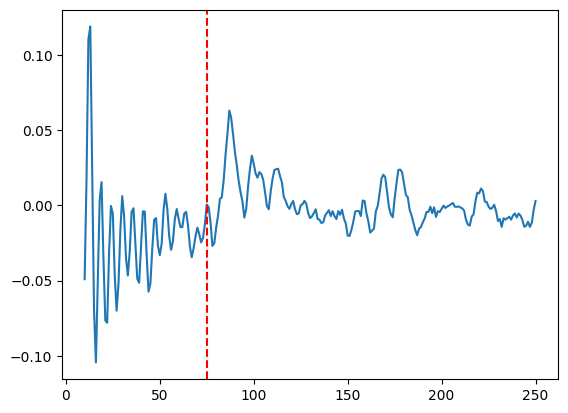

Generated z-score: 0.6094983969738689


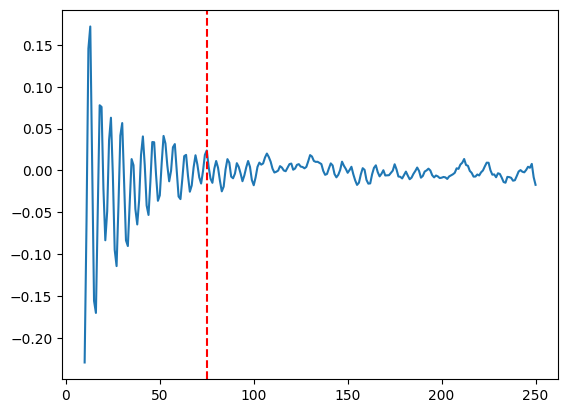

Generated z-score: 27.784028657054982


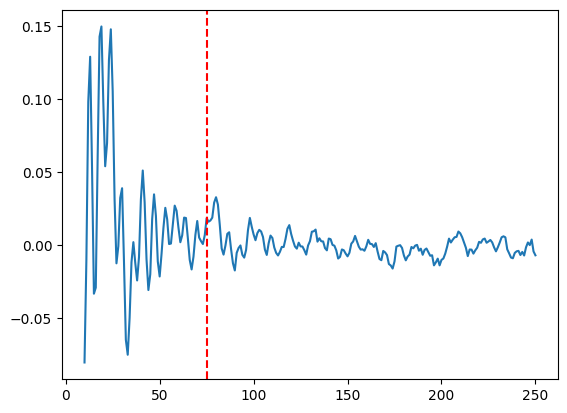

Generated z-score: 21.882688970942173


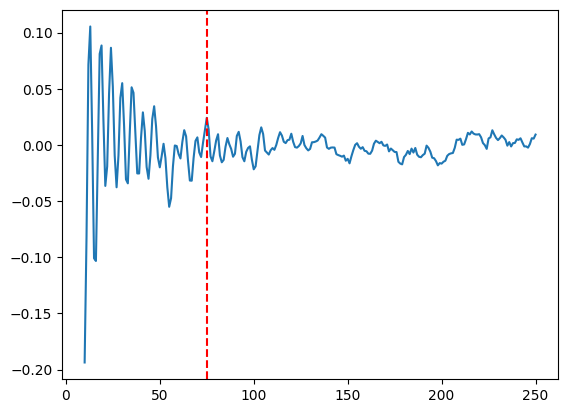

Generated z-score: 28.638343163257552


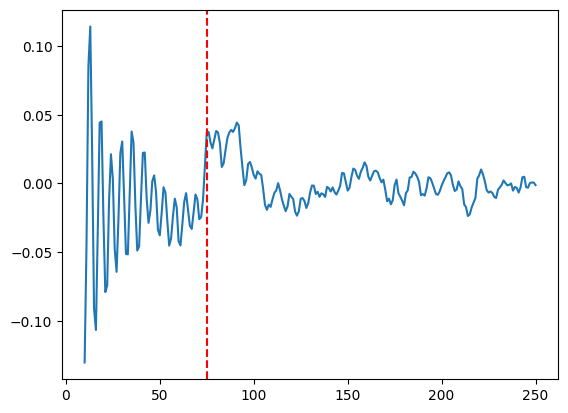

Generated z-score: 44.76522038117535


In [ ]:
# example cepstra
for i in range(5):
    ceps = get_cepstrum(all_gens_waveforms[i])
    ceps[:lag_start] = np.inf
    plt.plot(ceps[:lag_end+1])
    plt.axvline(x=75, color='red', linestyle='--')
    plt.show()

    zscore_gens = get_median_z_score(ceps, 75, start_buff=25)
    print("Generated z-score:", zscore_gens)

In [ ]:
def calculate_FAD_for_waveforms(reference : np.ndarray, generated : np.ndarray):
    metrics = AudioMetrics(
        metrics=["fad"],
        input_sr=sr,
    )

    metrics.add_reference(reference)
    return metrics.evaluate(generated)["fad"]

In [ ]:
ref = np.array(all_waveforms)
gens = np.array(all_gens_waveforms)
fad = calculate_FAD_for_waveforms(ref, gens)
print(f"FAD: {fad:.2f}")

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3613,) + inhomogeneous part.